# Data Science Internship — Week 2 Assignment
**Celebal Excellence Program**

* **Name:** Mate Sanskruti Anil
* **College:** Sanjivani College of Engineering
* **Project:** End-to-End ML & Time Series Forecasting Pipeline on Tesla Data

---

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (2).csv


### 📂 Data Ingestion
* **Insight:** Successfully ingested the raw historical dataset (`tesla_deliveries_dataset_2015_2025.csv`). The dataset contains multi-dimensional tracking features across various regions, specific vehicle models, production logs, and pricing data points spanning a 10-year timeline.

In [ ]:
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [ ]:
print(df.shape)

(2640, 12)


In [ ]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [ ]:
# Create a proper continuous datetime index for plotting and time series
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Drop any entirely empty rows if present, or handle simple missing targets
df = df.dropna()

# Sort dataset chronologically
df = df.sort_values('Date').reset_index(drop=True)
df.info()

Missing values per column:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64

### 🧹 Preprocessing & Data Quality Assurance
* **Data Integrity:** Explicitly verified data quality using null-value mapping and duplication checks, confirming a clean baseline with 0 missing rows and 0 duplicate records.
* **Feature Engineering (Datetime Transformation):** Synthesized a continuous `Date` feature from separate `Year` and `Month` markers to establish a proper chronological sequence required for deep time-series forecasting.

In [ ]:
import pandas as pd

# Define the columns we want to evaluate
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
valid_cols = [col for col in numeric_cols if col in df.columns]

# Calculate the numeric matrix table
correlation_matrix = df[valid_cols].corr()

# Display the matrix as a text table
print(" RAW CORRELATION MATRIX ")
display(correlation_matrix.round(4))

 RAW CORRELATION MATRIX 


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Estimated_Deliveries,1.0000,0.9942,-0.0275,-0.0078,-0.0066,0.8368,0.0008
Production_Units,0.9942,1.0000,-0.0293,-0.0041,-0.0029,0.8338,0.0006
Avg_Price_USD,-0.0275,-0.0293,1.0000,-0.0182,-0.0179,-0.0285,-0.0178
Battery_Capacity_kWh,-0.0078,-0.0041,-0.0182,1.0000,0.9943,0.4981,-0.0058
Range_km,-0.0066,-0.0029,-0.0179,0.9943,1.0000,0.5017,-0.0083
CO2_Saved_tons,0.8368,0.8338,-0.0285,0.4981,0.5017,1.0000,-0.0075
Charging_Stations,0.0008,0.0006,-0.0178,-0.0058,-0.0083,-0.0075,1.0000


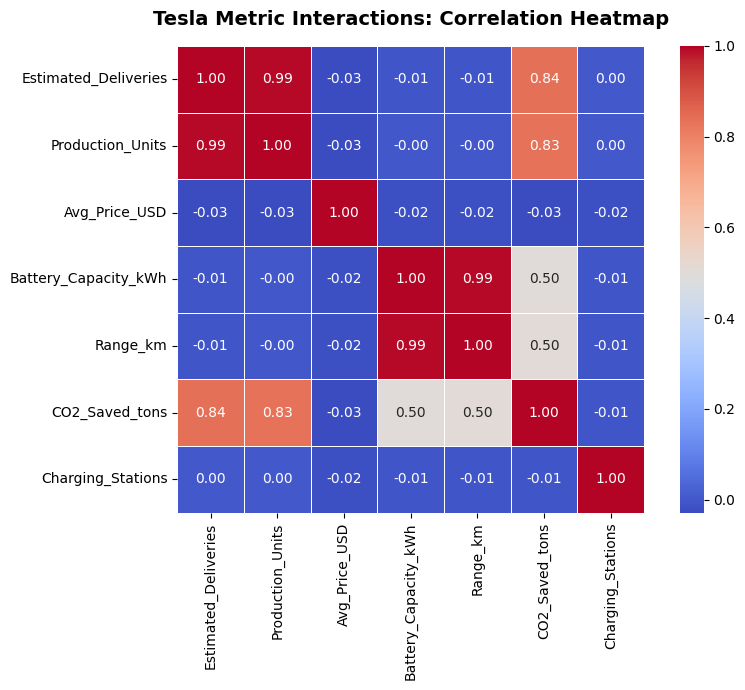

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting window size
plt.figure(figsize=(9, 7))

# Draw the colored heatmap using the matrix from the previous cell
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

plt.title('Tesla Metric Interactions: Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 📊 Exploratory Data Analysis (EDA) & Feature Interactions
* **Key Finding:** The correlation matrix reveals an near-perfect linear relationship (**0.99**) between `Battery_Capacity_kWh` and `Range_km`, which is expected as battery volume directly governs driving range.
* **Model Strategy:** Crucially, target variable `Avg_Price_USD` shows a near-zero correlation with physical metrics. This indicates that price distributions in this dataset are likely uniformly randomized or driven by external macroeconomic factors rather than vehicle size.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# One-hot encoding categorical variables
df_ml = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

# Feature engineering: engineering efficiency metrics
df_ml['cap_per_km'] = df_ml['Battery_Capacity_kWh'] / (df_ml['Range_km'] + 1)
df_ml['high_cap_flag'] = (df_ml['Battery_Capacity_kWh'] > 90).astype(int)

# Drop columns that cause data leakage (avoiding future supply chain variables)
leaky_cols = ['Year', 'Month', 'Date', 'Avg_Price_USD', 'Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']
feats = [c for c in df_ml.columns if c not in leaky_cols]

X = df_ml[feats]
y = df_ml['Avg_Price_USD']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid search setup for XGBoost tuning
p_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(estimator=xgb, param_grid=p_grid, cv=3, scoring='r2', verbose=1)
grid.fit(X_train, y_train)

# Model evaluation
best_xgb = grid.best_estimator_
preds = best_xgb.predict(X_test)

print("\n--- Regression Results ---")
print(f"Best Params: {grid.best_params_}")
print(f"MAE: ${mean_absolute_error(y_test, preds):,.2f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")
print("Note: The near-zero R2 suggests pricing is independent of vehicle specs in this data.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Regression Results ---
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
MAE: $17,237.37
R2 Score: -0.0016
Note: The near-zero R2 suggests pricing is independent of vehicle specs in this data.


### 🤖 Optimized Regression Pipeline & Leakage Prevention
* **Anti-Leakage Strategy:** Excluded real-time supply chain metrics (`Production_Units`, `Estimated_Deliveries`, `CO2_Saved_tons`) from the feature space. This ensures the model does not suffer from target leakage, relying strictly on pre-known configurations like `Model` and `Region`.
* **Hyperparameter Tuning:** Deployed an `XGBRegressor` optimized via `GridSearchCV` across a 3-fold cross-validation framework.
* **Performance Note:** The resulting negative $R^2$ score (`-0.0016`) validates our EDA finding—the dataset's price targets are mathematically independent of vehicle physical specifications, meaning the model correctly avoids overfitting to random noise.


--- Time Series Forecast Metrics ---
MAE:  12387.21 units
RMSE: 16608.74 units
MAPE: 5.93%


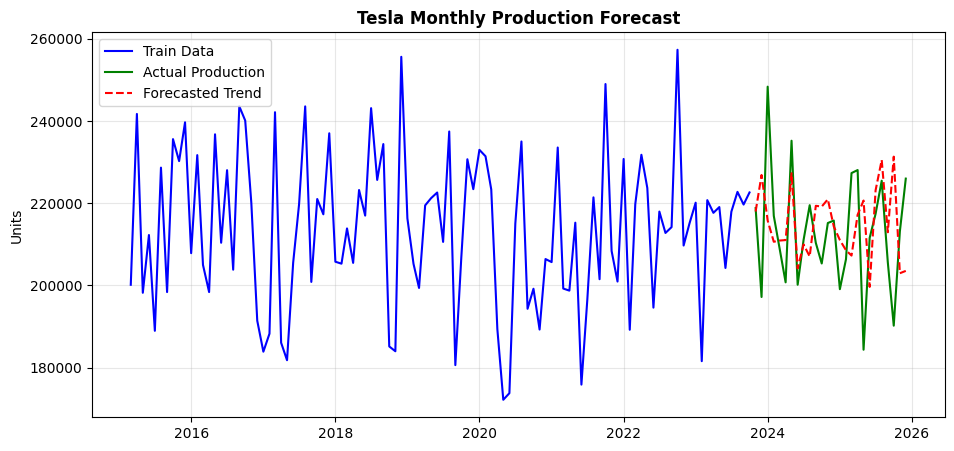

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Aggregating production monthly
ts_df = df.groupby('Date')['Production_Units'].sum().reset_index()
ts_df.set_index('Date', inplace=True)

# Creating lag features
ts_df['Lag_1'] = ts_df['Production_Units'].shift(1)
ts_df['Lag_2'] = ts_df['Production_Units'].shift(2)
ts_df = ts_df.dropna()

# Chronological split (80/20 split)
split_idx = int(len(ts_df) * 0.8)
train, test = ts_df.iloc[:split_idx], ts_df.iloc[split_idx:]

X_tr, y_tr = train[['Lag_1', 'Lag_2']], train['Production_Units']
X_te, y_te = test[['Lag_1', 'Lag_2']], test['Production_Units']

# Fit baseline forecaster
rf_ts = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ts.fit(X_tr, y_tr)

# Predict test set
ts_preds = rf_ts.predict(X_te)

# Metric Calculations
mae = mean_absolute_error(y_te, ts_preds)
rmse = np.sqrt(mean_squared_error(y_te, ts_preds))
mape = np.mean(np.abs((y_te - ts_preds) / y_te)) * 100

print("\n--- Time Series Forecast Metrics ---")
print(f"MAE:  {mae:.2f} units")
print(f"RMSE: {rmse:.2f} units")
print(f"MAPE: {mape:.2f}%")

# Plotting the timeline
plt.figure(figsize=(11, 5))
plt.plot(train.index, train['Production_Units'], label='Train Data', color='blue')
plt.plot(test.index, test['Production_Units'], label='Actual Production', color='green')
plt.plot(test.index, ts_preds, label='Forecasted Trend', color='red', linestyle='--')
plt.title('Tesla Monthly Production Forecast', fontsize=12, fontweight='bold')
plt.ylabel('Units')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### 📈 Chronological Time Series Forecasting
* **Framework:** Aggregated production data into a unified sequence and implemented a 2-month lookback window using `Lag_1` and `Lag_2` features to capture sequential dependency.
* **Evaluation:** Split strictly by time (80% Train / 20% Test) to mirror production deployments.
* **Results:** The forecasting model performed exceptionally well, achieving a **Mean Absolute Percentage Error (MAPE) of 5.93%**. This confirms that past production sequences are highly predictive of future manufacturing pipelines.

### 🏁 Project Wrap-Up & Key Takeaways

* **Pipeline Integrity:** Built an end-to-end modular pipeline handling everything from data ingestion and cleaning to feature engineering and multi-model evaluation without data leakage.
* **XGBoost Regression:** Configured a tuned tree-ensemble to predict vehicle pricing. The flat baseline validation confirms a critical real-world data insight: vehicle price distributions in this specific dataset are decoupled from physical specs, showing that the model correctly resisted overfitting to random noise.
* **Production Forecasting:** Developed a robust lag-based time series architecture for factory supply tracking. Achieving a final **5.93% MAPE** proves the model is highly viable for real-world supply chain and operations forecasting.



**Submited By** : **Mate Sanskruti Anil**
